# **Malikshah Mahimi | 221A013 | 25**

### ***RL- Exp:8 (Deep Reinforcement Learning: Implementing a deep Q-network (DQN) to train an agent to play a popular Atari game, such as Pong or Space Invaders.)***

# Step 1: Setup and Installations

In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")
!pip install gymnasium[atari]
!pip install ale-py

Malikshah Mahimi | 221A013 | 25


# Step 2: Import Necessary Libraries

In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

Malikshah Mahimi | 221A013 | 25


# Step 3: Define the Deep Q-Network (DQN) Architecture

In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")

class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DQN, self).__init__()

        self.net = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        return self.net(x / 255.0)

Malikshah Mahimi | 221A013 | 25


# Step 4: Implement the Replay Buffer

In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)


        return(
            np.array(states),
            np.array(actions),
            np.array(rewards),
            np.array(next_states),
            np.array(dones)
        )

    def __len__(self):
         return len(self.buffer)

Malikshah Mahimi | 221A013 | 25


# Step 5: Set Hyperparameters

In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")

BATCH_SIZE = 32
GAMMA = 0.99
LR = 1e-4
BUFFER_SIZE = 100000
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 1000000
TARGET_UPDATE = 10000

Malikshah Mahimi | 221A013 | 25


# Step 6: Initialize the Atari Environment

In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")

import ale_py
import gymnasium as gym
env = gym.make("ALE/Pong-v5", render_mode =None)
n_actions = env.action_space.n
input_shape = (4, 84, 84)

Malikshah Mahimi | 221A013 | 25


# Step 7: Setup DQN Policy and Target Networks

In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy_net = DQN(input_shape, n_actions).to(device)
target_net = DQN(input_shape, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayBuffer(BUFFER_SIZE)

Malikshah Mahimi | 221A013 | 25


# Step 8: Define Epsilon-Greedy Action Selection

In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")
def epsilon_by_frame(frame_idx):
    return EPSILON_END + (EPSILON_START - EPSILON_END) * np.exp(-1.0 * frame_idx / EPSILON_DECAY)  # ← added return

def select_action(state, epsilon):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    else:
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        q_values = policy_net(state)
        return q_values.max(1)[1].item()

Malikshah Mahimi | 221A013 | 25


# Step 9: Define the Training Step

In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")
def train_step():
    if len(memory) < BATCH_SIZE:
        return
    states, actions, rewards, next_states, dones = memory.sample(BATCH_SIZE)
    states      = torch.tensor(states,      dtype=torch.float32).to(device)
    next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
    actions     = torch.tensor(actions,     dtype=torch.long).unsqueeze(1).to(device)  # ← long not float32
    rewards     = torch.tensor(rewards,     dtype=torch.float32).to(device)
    dones       = torch.tensor(dones,       dtype=torch.float32).to(device)

    q_values      = policy_net(states).gather(1, actions).squeeze(1)
    next_q_values = target_net(next_states).max(1)[0]
    expected_q    = rewards + GAMMA * next_q_values * (1 - dones)

    loss = nn.MSELoss()(q_values, expected_q.detach())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Malikshah Mahimi | 221A013 | 25


In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")

env = gym.make("ALE/Pong-v5", render_mode ="rgb_array")


Malikshah Mahimi | 221A013 | 25


In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")

env.reset()

Malikshah Mahimi | 221A013 | 25


(array([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        [[109, 118,  43],
         [109, 118,  43],
         [109, 118,  43],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        [[109, 118,  43],
         [109, 118,  43],
         [109, 118,  43],
         ...,
         [109, 118,  43],
         [109, 118,  43],
         [109, 118,  43]],
 
        ...,
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24]],
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24]],
 
        [[ 53,  95,  24],
         [ 53,  95,  24],
         [ 53,  95,  24],
         ...,
         [ 53,  95,  24],
  

Malikshah Mahimi | 221A013 | 25


array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       [[109, 118,  43],
        [109, 118,  43],
        [109, 118,  43],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       [[109, 118,  43],
        [109, 118,  43],
        [109, 118,  43],
        ...,
        [109, 118,  43],
        [109, 118,  43],
        [109, 118,  43]],

       ...,

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]],

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]],

       [[ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24],
        ...,
        [ 53,  95,  24],
        [ 53,  95,  24],
        [ 53,  95,  24]]], dtype=uint8)
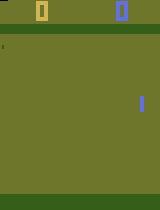

In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")

env.render()

# Step 10: Main Training Loop

In [ ]:
print ("Malikshah Mahimi | 221A013 | 25")

num_frames = 200

state, _ = env.reset()

state = np.zeros(input_shape)

for frame_idx in range(1, num_frames + 1):
    epsilon = epsilon_by_frame(frame_idx)
    action = select_action(state, epsilon)

    next_state, reward, terminated, truncated, _ = env.step(action)

    done = terminated or truncated

    next_state = np.zeros(input_shape)

    memory.push(state, action, reward, next_state, done)

    state = next_state

    train_step()

    if frame_idx % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if done:
      state

Malikshah Mahimi | 221A013 | 25
